## Example 5: Sparse Randomly Chosen Reactions from 4D System

In [5]:
import sys
import os

# Add repo root to Python path (one level up from examples/)
sys.path.append(os.path.abspath(".."))  

from src.parsing import *
from src.inference import *
from src.mcmc import *
from CRN_Simulation.CRN import CRN

import numpy as np
import random

In [6]:
# Potentially make something that would generate all the complexes and such.
# Could generalize more.

# Define species names
species_names = ["A", "B", "X","Y"]

# Define complexes — dimension is (# species) x (# complexes)
# Each column is a complex: [A, B, X, Y]
complexes = np.array([
    # 0   A   B   X   Y  2A  2B  2X  2Y  A+B A+X A+Y B+X B+Y X+Y
    [  0,  1,  0,  0,  0,  2,  0,  0,  0,  1,  1,  1,  0,  0,  0],  # A
    [  0,  0,  1,  0,  0,  0,  2,  0,  0,  1,  0,  0,  1,  1,  0],  # B
    [  0,  0,  0,  1,  0,  0,  0,  2,  0,  0,  1,  0,  1,  0,  1],  # X
    [  0,  0,  0,  0,  1,  0,  0,  0,  2,  0,  0,  1,  0,  1,  1],  # Y
])

# Create Reactant, Product, Stochiometric Matrix, Define Compatible Reactions and Everything Needed for CRN
reactant_matrix, product_matrix, stoichiometric_matrix, reaction_names, parameter_names, unique_changes, compatible_reactions = generate_reactions(complexes, species_names)

# Plot some output to the screen
print(f"Total reactions generated: {len(reaction_names)}")
max_show = 3
print("Some Reaction Names:", reaction_names[:max_show])

print("\nStoichiometric Changes (Grouped by Unique ΔX):")
print("------------------------------------------------")

count_shown = 0

for deltaX in unique_changes:            # <-- ordered, stable, consistent
    rxn_indices = compatible_reactions[deltaX]
    deltaX_clean = tuple(int(x) for x in deltaX)

    # Only show groups with >1 reaction if desired
    # Remove this if you want *all* ΔX shown
    if len(rxn_indices) <= 1:
        continue

    # Collect human-readable reaction names
    rxn_names = [reaction_names[i] for i in rxn_indices]

    print(f"ΔX = {deltaX_clean}")
    print(f"  Reaction indices: {rxn_indices}")
    print("  Reactions:")
    for idx, rname in zip(rxn_indices, rxn_names):
        print(f"    {idx}: {rname}")
    print()

    count_shown += 1
    if count_shown >= max_show:
        break

Total reactions generated: 210
Some Reaction Names: ['Empty_to_A:', 'Empty_to_B:', 'Empty_to_X:']

Stoichiometric Changes (Grouped by Unique ΔX):
------------------------------------------------
ΔX = (1, 0, 0, 0)
  Reaction indices: [0, 18, 36, 51, 66]
  Reactions:
    0: Empty_to_A:
    18: A_to_2A:
    36: B_to_A+B:
    51: X_to_A+X:
    66: Y_to_A+Y:

ΔX = (0, 1, 0, 0)
  Reaction indices: [1, 22, 33, 53, 68]
  Reactions:
    1: Empty_to_B:
    22: A_to_A+B:
    33: B_to_2B:
    53: X_to_B+X:
    68: Y_to_B+Y:

ΔX = (0, 0, 1, 0)
  Reaction indices: [2, 23, 39, 48, 69]
  Reactions:
    2: Empty_to_X:
    23: A_to_A+X:
    39: B_to_B+X:
    48: X_to_2X:
    69: Y_to_X+Y:



In [7]:
# Number of Reactions to Sample and Gamma Prior
N = 20
alpha, beta = 2.6, 0.4

(CRN_stoichiometric_matrix, CRN_reaction_names, CRN_parameter_names,
 CRN_propensities, trueTheta, parameter_values, sampled_indices) = build_CRN_bySamplingReactions_withConstraints(
        reactant_matrix, product_matrix, stoichiometric_matrix,
        reaction_names, parameter_names, species_names,
        unique_changes, compatible_reactions,
        N=20, n_ambiguous_changes=4, min_reactions_per_change=2,
        alpha=2.6, beta=0.4, seed=19, verbose=True)

# Create Reaction Network with CRN_Simulation.CRN
reactionNetwork = CRN(species_names=species_names,
         stoichiometric_matrix=CRN_stoichiometric_matrix,
         parameters_names=CRN_parameter_names,
         reaction_names=CRN_reaction_names,
         propensities=CRN_propensities)

# Save Reaction Network for Additional Analysis if Needed
save_reaction_network(
    species_names, reactant_matrix,
    CRN_stoichiometric_matrix, CRN_reaction_names, CRN_parameter_names,
    trueTheta, parameter_values, sampled_indices,
    unique_changes, compatible_reactions,
    filename="../data/example5_network.json"
)


[Constraint] Guaranteeing 4 ambiguous stoichiometric changes:
  ΔX=(0, 1, 0, 0)  →  5 compatible reactions available
  ΔX=(0, 0, 0, -1)  →  5 compatible reactions available
  ΔX=(0, 0, 0, 1)  →  5 compatible reactions available
  ΔX=(0, 1, 0, -1)  →  5 compatible reactions available
  Guaranteed reaction indices (8 total): [22, 53, 155, 199, 63, 24, 208, 163]
  Filler reactions sampled: 12
  Total sampled: 20

Sampling 20 reactions out of 210 total.

Index  Param    Reaction Name                  Value    Guaranteed
-----------------------------------------------------------------
22     k22      A_to_A+B:                      1.046    ✓
53     k53      X_to_B+X:                      0.717    ✓
155    k155     A+Y_to_A:                      0.590    ✓
199    k199     X+Y_to_X:                      0.768    ✓
63     k63      Y_to_2Y:                       1.067    ✓
24     k24      A_to_A+Y:                      0.280    ✓
208    k208     X+Y_to_B+X:                    0.906    ✓
163  

Initial state: {'A': 5, 'B': 5, 'X': 5, 'Y': 5}
Initial state: {'A': 5, 'B': 5, 'X': 5, 'Y': 5}
Trajectory saved to ../data/example5_T200_trajectory.json
Trajectory saved to ../data/example5_T400_trajectory.json


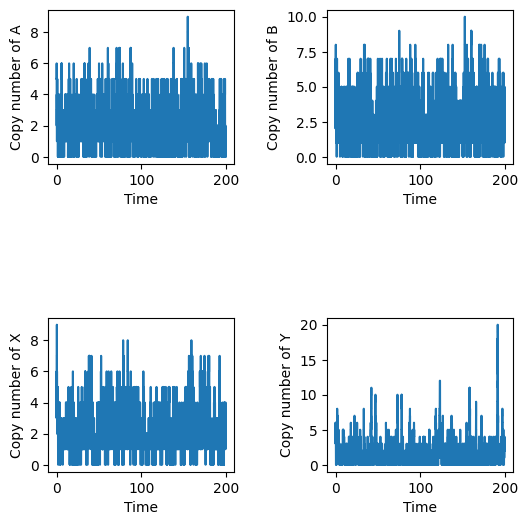

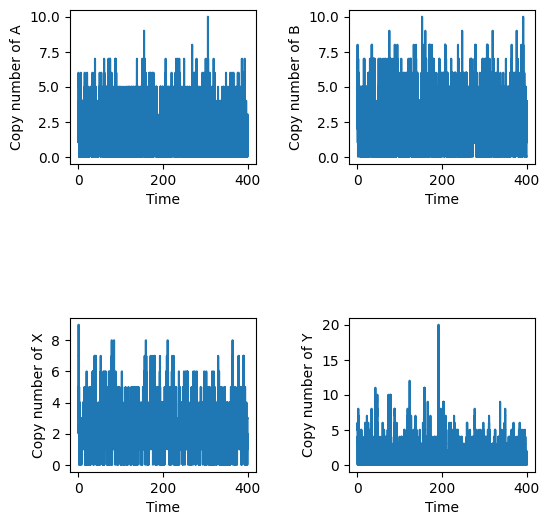

In [4]:
data_dir = "../data"  # relative to examples/ folder
os.makedirs(data_dir, exist_ok=True)

Tfinal1 = 100
Tfinal2 = 200
Tfinal3 = 400

# Generate trajectory (T = 100)
time_list1, state_list1 = generate_single_trajectory(
    reactionNetwork,
    parameter_values,
    species_names,
    finalTime=Tfinal1,   # adjust as needed
    minVal=5,
    maxVal=5,
    seed=42          # for reproducibility
)

# Generate trajectory (T = 200)
time_list2, state_list2 = generate_single_trajectory(
    reactionNetwork,
    parameter_values,
    species_names,
    finalTime=Tfinal2,   # adjust as needed
    minVal=5,
    maxVal=5,
    seed=42          # for reproducibility
)

# Generate trajectory (T = 400)
time_list3, state_list3 = generate_single_trajectory(
    reactionNetwork,
    parameter_values,
    species_names,
    finalTime=Tfinal3,   # adjust as needed
    minVal=5,
    maxVal=5,
    seed=42          # for reproducibility
)

# Save trajectory to JSON
trajectory_file = os.path.join(data_dir, "example5_T100_trajectory.json")
save_trajectory(time_list1, state_list1, filename=trajectory_file)

# Save trajectory to JSON
trajectory_file = os.path.join(data_dir, "example5_T200_trajectory.json")
save_trajectory(time_list2, state_list2, filename=trajectory_file)

# Save trajectory to JSON
trajectory_file = os.path.join(data_dir, "example5_T400_trajectory.json")
save_trajectory(time_list3, state_list3, filename=trajectory_file)

## Parsing Trajectory 1 (TFinal = 200)

Parsing Trajectory
Tracking 130 unique stoichiometric changes.
Trajectory length: 8144 timepoints. Iterating to len-2 to avoid final non-jump.
Finished parsing trajectory. Observed 1567 unique states.
---------
Finished parsing trajectories. Summary:
Trajectory 1: 1567 unique states observed


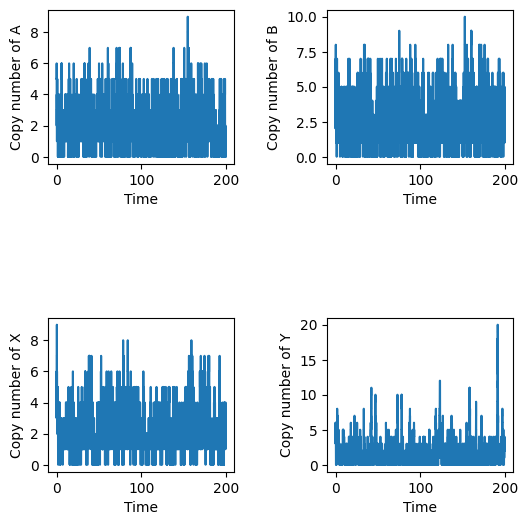

In [5]:
trajectory_file_new = "../data/example5_T200_trajectory.json"
time_list_new, state_list_new = load_trajectory(trajectory_file_new)
reactionNetwork.plot_trajectories(time_list_new, state_list_new)

time_list = time_list_new
state_list = state_list_new

# Parse trajectories for CRN1
print("Parsing Trajectory")
unique_states, jump_counts, waiting_times, propensities = parse_trajectory(
    state_list,time_list,reactant_matrix,unique_changes,compatible_reactions,verbose=True)
print("---------")

# Print basic summary
print("Finished parsing trajectories. Summary:")
print(f"Trajectory 1: {len(unique_states)} unique states observed")

## Parsing Trajectory 2 (TFinal = 400)

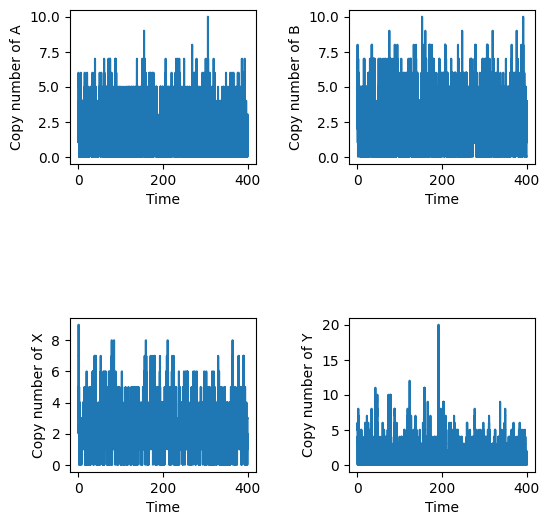

In [7]:
trajectory_file_new = "../data/example5_T400_trajectory.json"
time_list_new, state_list_new = load_trajectory(trajectory_file_new)
reactionNetwork.plot_trajectories(time_list_new, state_list_new)

time_list = time_list_new
state_list = state_list_new

In [8]:
# Parse trajectories for CRN1
print("Parsing Trajectory")
unique_states, jump_counts, waiting_times, propensities = parse_trajectory(
    state_list,time_list,reactant_matrix,unique_changes,compatible_reactions,verbose=True)
print("---------")

# Print basic summary
print("Finished parsing trajectories. Summary:")
print(f"Trajectory 1: {len(unique_states)} unique states observed")

Parsing Trajectory
Tracking 130 unique stoichiometric changes.
Trajectory length: 16117 timepoints. Iterating to len-2 to avoid final non-jump.
Finished parsing trajectory. Observed 1887 unique states.
---------
Finished parsing trajectories. Summary:
Trajectory 1: 1887 unique states observed
